# 01 — Le signal RR : brique de base de l'HRV

Un **intervalle RR** est le temps (en millisecondes) entre deux battements cardiaques
consécutifs. C'est la matière première de toute analyse HRV.

À 60 bpm le cœur bat toutes les 1000 ms → RR ≈ 1000 ms.  
À 80 bpm → RR ≈ 750 ms. Plus le cœur bat vite, plus les RR sont courts.

Ce notebook couvre :
1. Lire un fichier Polar `.txt` → `RRSeries`
2. Comprendre et détecter les artefacts physiologiques
3. Nettoyer le signal
4. Visualiser : tachogramme, distribution, signal filtré, résumé complet

In [1]:
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("inline")
import matplotlib.pyplot as plt

import cardiolab
from cardiolab.features.time_domain import rmssd
from cardiolab.sensors_tools.polar import parse_rr_file
from cardiolab.signals.rr import PhysiologicalWarning, RRSeries
from cardiolab.visualization.rr_plots import (
    plot_rr_distribution,
    plot_rr_filtered,
    plot_rr_summary,
    plot_rr_tachogram,
)

# Dossier datasets embarqué dans le package
DATASETS_DIR = Path(cardiolab.__file__).parent / "datasets"
RESTING_DIR  = DATASETS_DIR / "raw" / "resting"

files = sorted(RESTING_DIR.glob("*.txt"))
print(f"Fichiers disponibles ({len(files)}) :")
for f in files:
    print(f"  {f.name}")

Fichiers disponibles (6) :
  2026-04-24 07-52-36.txt
  2026-04-25 07-58-25.txt
  2026-04-26 07-40-41.txt
  2026-04-27 07-01-19.txt
  2026-04-28 07-01-05.txt
  2026-04-30 07-01-38.txt


## 1 — Lecture d'un fichier Polar

`parse_rr_file()` détecte automatiquement le format (`.txt`, `.csv`) et retourne
un dict avec les intervalles RR bruts en millisecondes.

In [2]:
# Lire le premier fichier de la série
raw = parse_rr_file(files[0])

print(f"Fichier    : {raw['source']}")
print(f"Format     : {raw['format']}")
print(f"Intervalles: {raw['count']} battements")
print(f"Durée      : {raw['duration_sec']:.0f} s ({raw['duration_sec']/60:.1f} min)")
print(f"\n5 premiers RR : {raw['rr_intervals'][:5]} ms")
print(f"HR moyen       : {60_000 / (sum(raw['rr_intervals']) / len(raw['rr_intervals'])):.1f} bpm")

Fichier    : 2026-04-24 07-52-36.txt
Format     : .txt
Intervalles: 320 battements
Durée      : 332 s (5.5 min)

5 premiers RR : [832.0, 834.0, 873.0, 939.0, 867.0] ms
HR moyen       : 57.9 bpm


## 2 — Créer une RRSeries

`RRSeries` est le conteneur typé de cardiolab. Il valide automatiquement que
les intervalles sont dans la plage physiologique [300 – 2000 ms], ce qui correspond
à [30 – 200 bpm]. Toute valeur hors plage déclenche un `PhysiologicalWarning` :
c'est souvent un artefact de mouvement ou un battement ectopique.

In [3]:
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    rr = RRSeries(raw["rr_intervals"])

if w:
    for warning in w:
        if issubclass(warning.category, PhysiologicalWarning):
            print(f"⚠️  {warning.message}")
else:
    print("✓  Signal propre — aucun intervalle hors plage [300–2000 ms]")

print(f"\nRRSeries : {len(rr.intervals)} intervalles | "
      f"HR moyen {rr.mean_hr:.1f} bpm | "
      f"RMSSD {rmssd(rr):.1f} ms")

✓  Signal propre — aucun intervalle hors plage [300–2000 ms]

RRSeries : 320 intervalles | HR moyen 57.9 bpm | RMSSD 78.5 ms


## 3 — Tachogramme

Le **tachogramme** trace l'évolution des intervalles RR dans le temps.
On y cherche :
- des **oscillations respiratoires** (variation lente, ~0.25 Hz) → signe de bonne variabilité
- des **pics isolés** très courts ou très longs → artefacts ou ectopiques
- une **dérive progressive** → fatigue ou artefact de mouvement

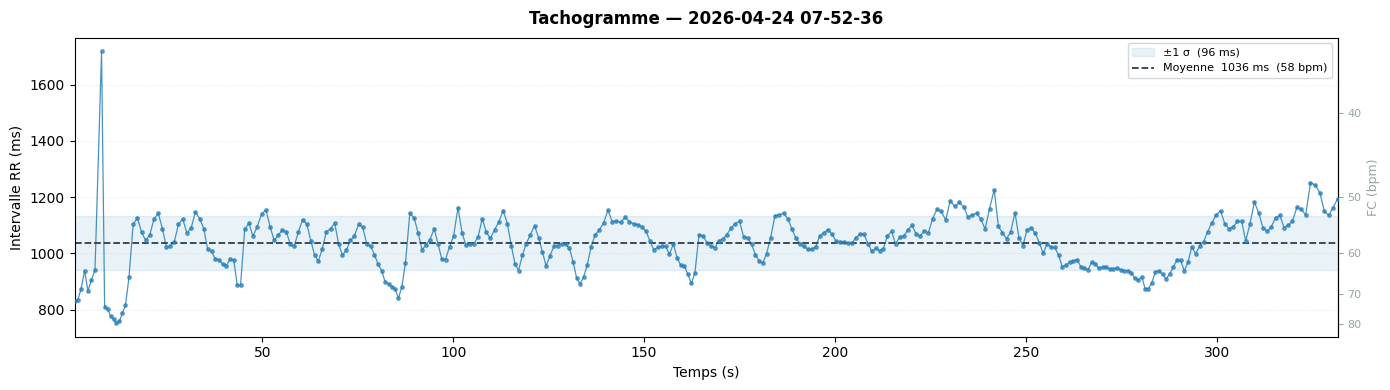

In [4]:
fig = plot_rr_tachogram(rr, show_mean=True, show_band=True, show_hr_axis=True,
                         title=f"Tachogramme — {files[0].stem}")
plt.show()

## 4 — Distribution des intervalles

La **distribution** des RR doit être approximativement gaussienne pour un enregistrement
de repos. Un étalement large indique une bonne HRV (système nerveux autonome actif).
Une distribution étroite et pointue signale une HRV faible (fatigue, stress).

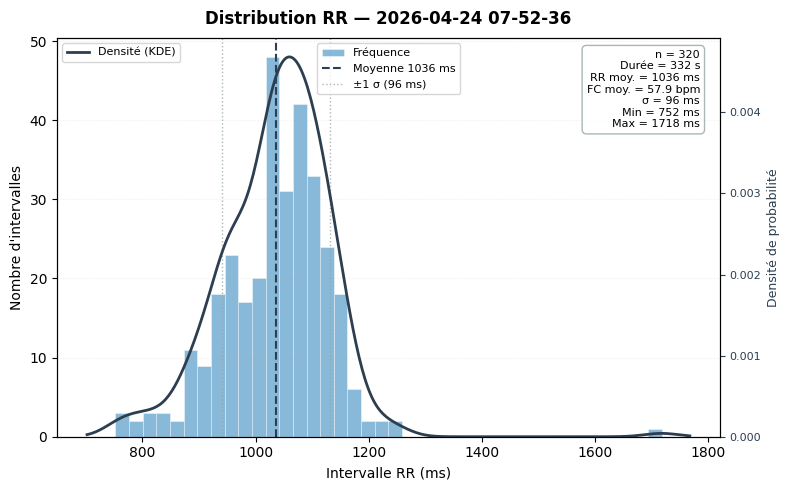

In [5]:
fig = plot_rr_distribution(rr, title=f"Distribution RR — {files[0].stem}")
plt.show()

## 5 — Nettoyage du signal

`remove_outliers()` supprime les battements ectopiques et artefacts par **z-score** :
tout intervalle déviant de plus de 3 σ de la médiane locale est remplacé par
interpolation linéaire. Cette étape est recommandée avant toute analyse HRV.

> **Règle pratique :** si plus de 5 % des battements sont filtrés, la qualité du signal
> est insuffisante — répéter l'enregistrement.

Intervalles supprimés : 1 / 320 (0.3 %)
✓  Signal de bonne qualité

RMSSD brut   : 78.5 ms
RMSSD nettoyé: 41.6 ms


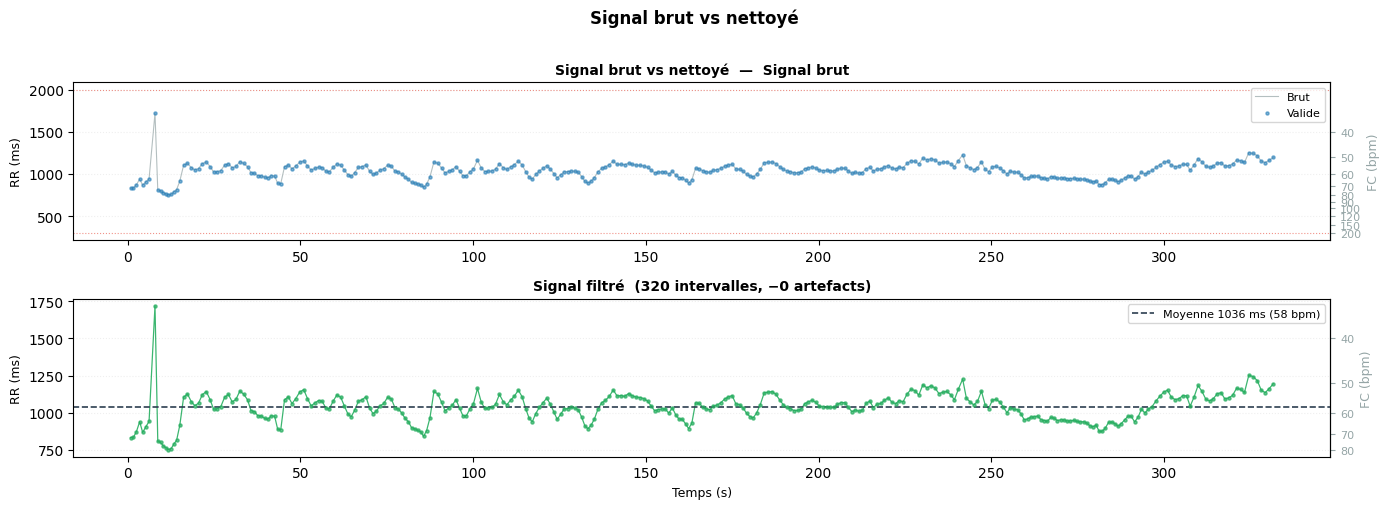

In [6]:
rr_clean = rr.remove_outliers(method="zscore")

n_removed = len(rr.intervals) - len(rr_clean.intervals)
pct = n_removed / len(rr.intervals) * 100
print(f"Intervalles supprimés : {n_removed} / {len(rr.intervals)} ({pct:.1f} %)")

if pct > 5:
    print("⚠️  Plus de 5 % filtrés — qualité du signal à vérifier")
else:
    print("✓  Signal de bonne qualité")

print(f"\nRMSSD brut   : {rmssd(rr):.1f} ms")
print(f"RMSSD nettoyé: {rmssd(rr_clean):.1f} ms")

fig = plot_rr_filtered(rr, title="Signal brut vs nettoyé")
plt.show()

## 6 — Résumé 2×2

Vue d'ensemble compacte : tachogramme + distribution + PSD + statistiques HRV.

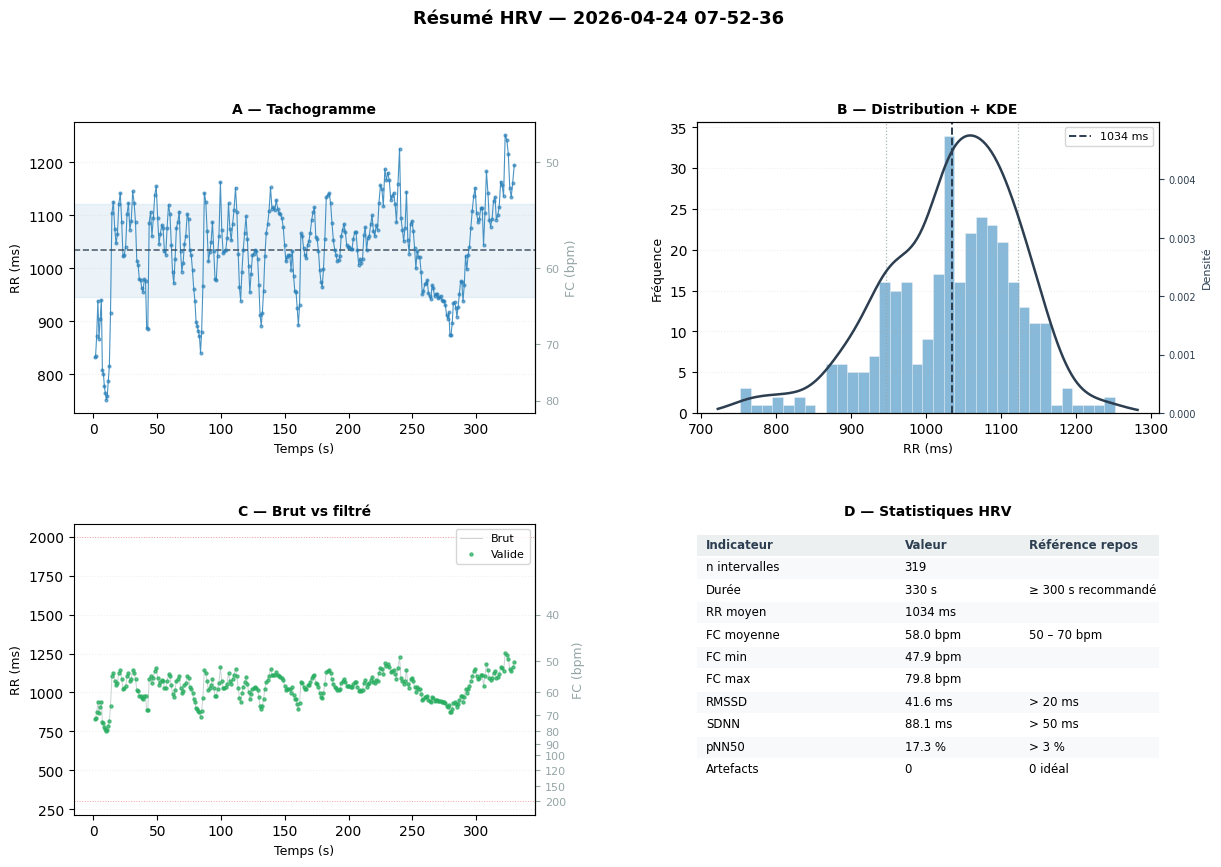

In [7]:
fig = plot_rr_summary(rr_clean, title=f"Résumé HRV — {files[0].stem}")
plt.show()

## 7 — Comparer plusieurs sessions

Charger et comparer les 6 sessions disponibles.

  2026-04-24   320 batt  HR 57.9 bpm  RMSSD 78.5 ms
  2026-04-25   591 batt  HR 52.2 bpm  RMSSD 51.8 ms
  2026-04-26   307 batt  HR 55.3 bpm  RMSSD 53.5 ms
  2026-04-27   296 batt  HR 53.5 bpm  RMSSD 52.6 ms
  2026-04-28   299 batt  HR 53.9 bpm  RMSSD 59.9 ms
  2026-04-30   283 batt  HR 51.0 bpm  RMSSD 81.9 ms


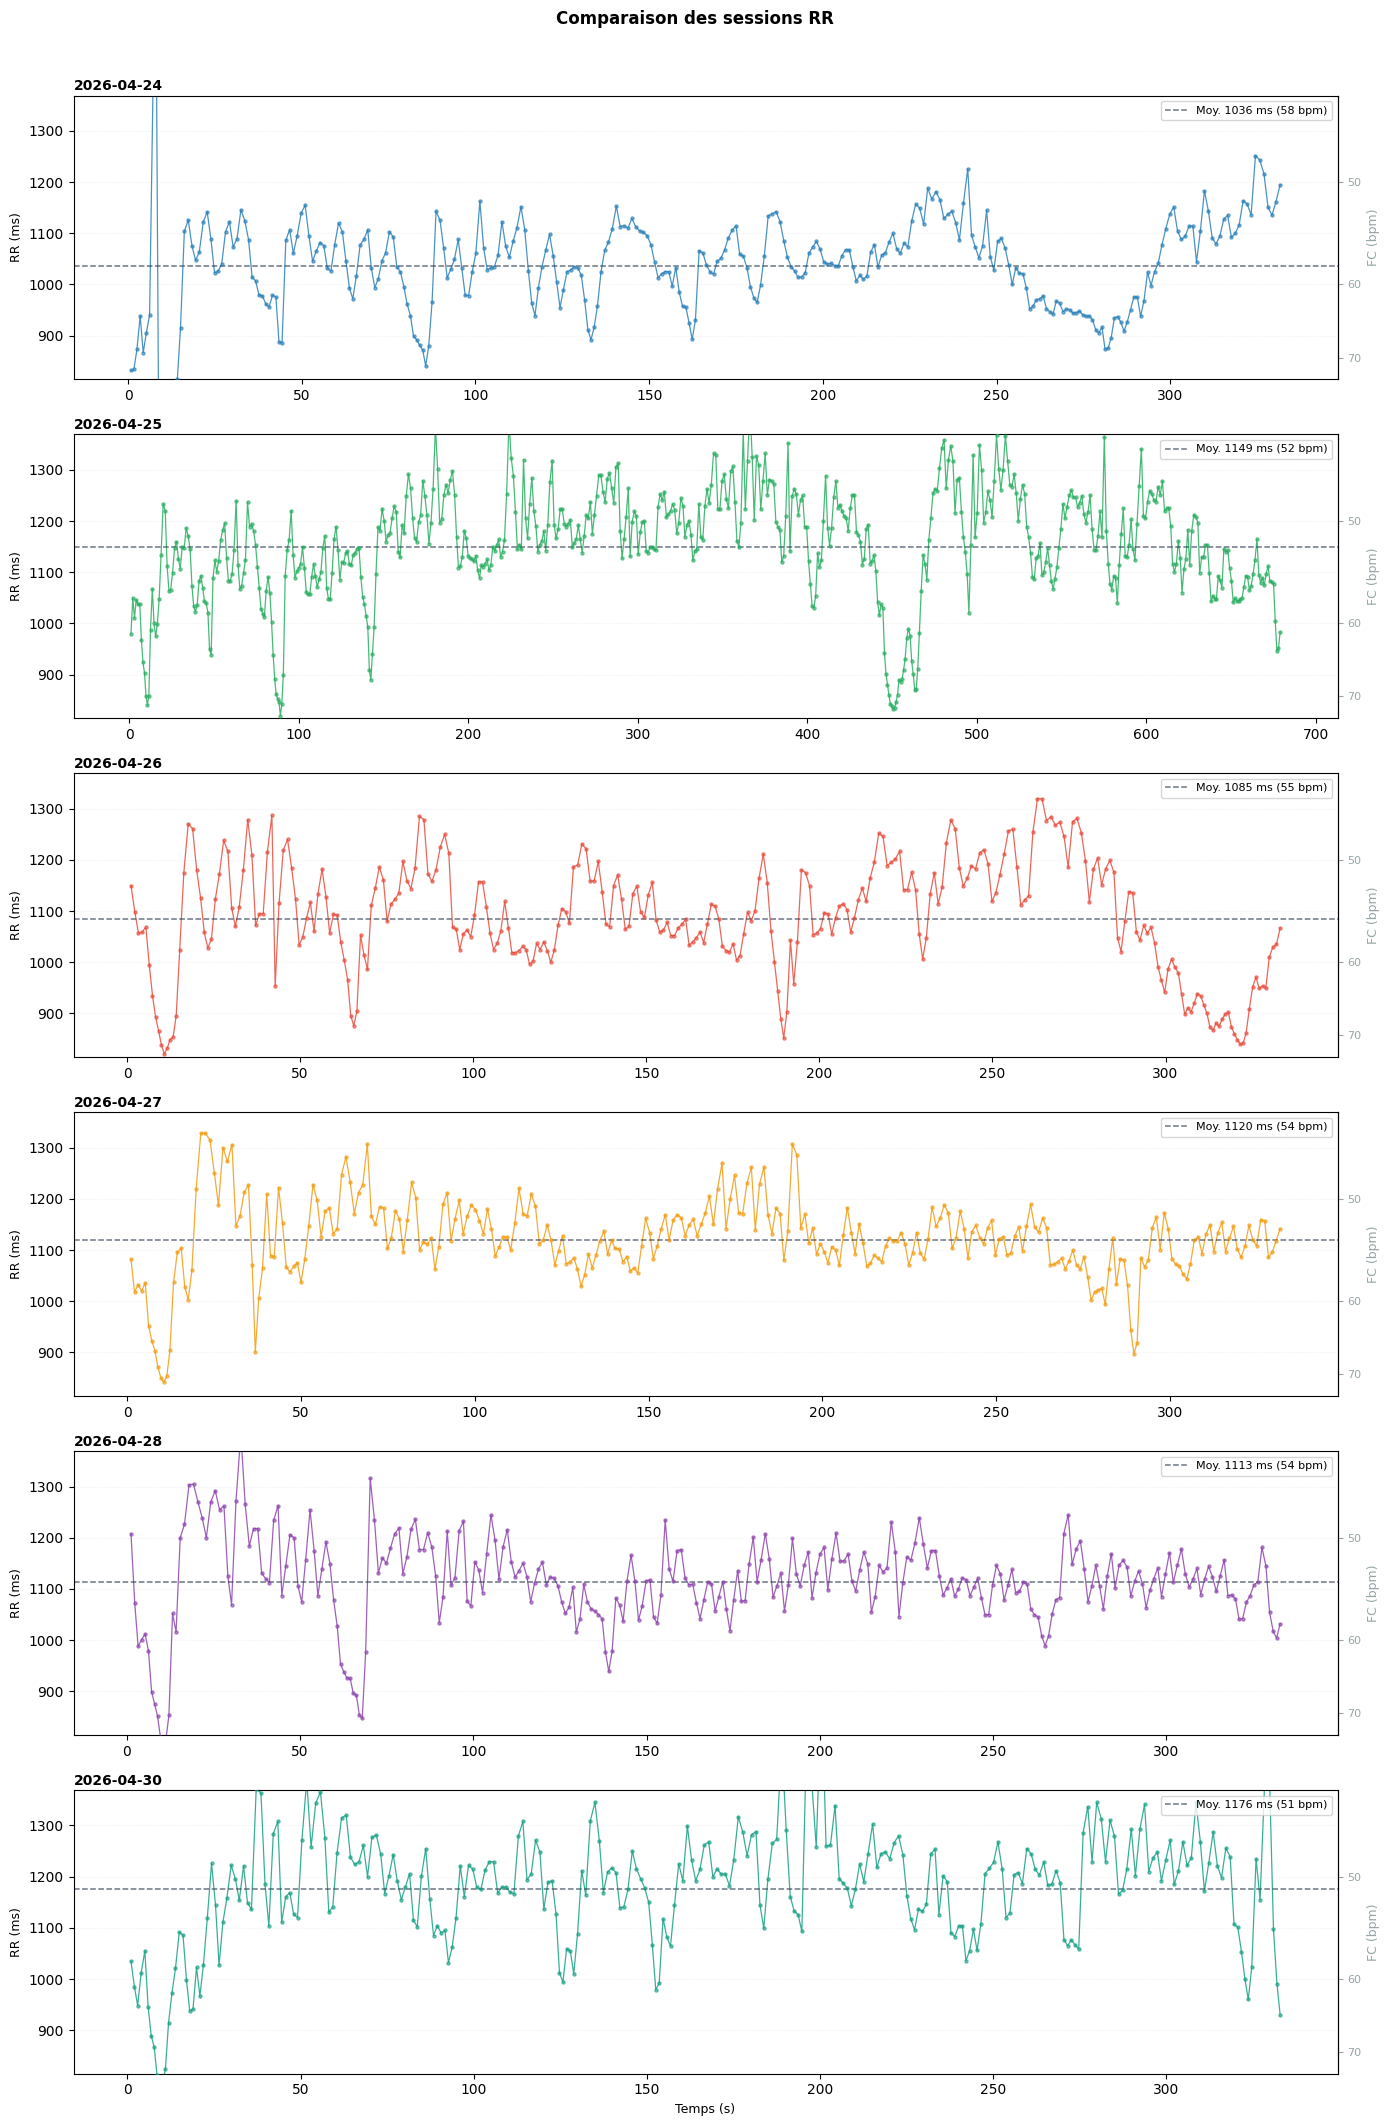

In [8]:
from cardiolab.visualization.rr_plots import plot_rr_comparison

rr_list = []
labels  = []
for f in files:
    raw_data = parse_rr_file(f)
    rr_s = RRSeries(raw_data["rr_intervals"]).remove_outliers()
    rr_list.append(rr_s)
    labels.append(f.stem[:10])  # garder la date uniquement
    print(f"  {f.stem[:10]}  {len(rr_s.intervals):4d} batt  "
          f"HR {rr_s.mean_hr:.1f} bpm  RMSSD {rmssd(rr_s):.1f} ms")

fig = plot_rr_comparison(rr_list, labels=labels,
                          title="Comparaison des sessions RR")
plt.show()